In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

# Assumptions

In [81]:
# Gas Truck Aassumptions
g_tube_unit = 574000 #$/module
g_trailer = 60000 #$/trailer
g_variable_o_m = 0.01 # for Non-Fuel
g_fixed_o_m = 0.04
crf_tube_trailer = 0.12
g_truck_capacity = 796 #kg/truck
g_pmax = 500  # 500 atm
g_pmin = 50 # atm
g_net_delivery = 660.68 #kg/truck key issue
g_load_unload_time = 3 #hours/ trip

In [82]:
# Liquid Truck Assumptions

l_tank_unit = 890000 #$/module
l_trailer = 60000 #$/trailer
l_variable_o_m = 0.01 # for Non-Fuel
l_fixed_o_m = 0.04
crf_tank_trailer = 0.12
l_truck_boil_off_rate = 0.30 # %/day
l_truck_capacity = 4000 # kg/truck
l_load_unload_time = 5.5 #hr/ trip

In [83]:
# General Truck Assumptions
cab_cost = 350000 #$/ cab
crf_cab = 0.26
fuel_economy = 7.11 # miles/kg of hydrogen
average_speed = 40 #km/hr
truck_availability = 24 #hr/day
hour_per_driver = 9.8 #hr/driver
driver_wage_benefits = 24.74 #$/hr
truck_cf = 0.8 # truck capacity factor
driving_circuity_factor = 0
fuel_price = 9 # $/kg

In [84]:
# Liquefaction Assumptions

l_base_plant_size = 20000 #kg/day
l_cost_base_plant = 62000000 # $
scale_factor_liquefier = 0.80
CRF_liquefier = 0.1
l_energy_use = 10.316667 # kWh/kg
l_electricity_cost = 0.080 # $/kWh
l_o_and_m_cost = 0.05

# Compression

c_energy_use = 3.41286114500405 # kWh/d
c_overcapacity = 0.2308
c_base_size = 20 #kW
c_base_cost = 245353
c_scale_factor = 0.46
c_crf = 0.13
c_o_and_m_cost = 0.04
c_electricity_cost = 0.08 # $/kWh

In [85]:
# Electricity 

electricity_cost = 0.08
ca_primary_energy = 2.5 #ratio
elec_CO2_emissions = 369 # grams/ kWh

annual_plant_cf = 1
h_fuel_ci = 4840 # kg of CO2e/kg H2

In [86]:
# =========================================================
# LEAKAGE RATES — TRANSMISSION
# =========================================================

leak_gas_truck_trans = 0.0106      # fraction (1.06%)
leak_liquid_truck_trans = 0.0255   # fraction (2.55%)
leak_pipeline_trans = 0.0003       # fraction (0.03%)

# =========================================================
# LEAKAGE RATES — DISTRIBUTION
# =========================================================

leak_gas_truck_dist = 0.0018       # fraction (0.18%)
leak_liquid_truck_dist = 0.0300    # fraction (3.0%)
leak_pipeline_dist = 0.0255        # fraction (2.55%)

# =========================================================
# STATION LOSSES
# =========================================================

leak_gas_station = 0.0041          # fraction (0.41%)
leak_liquid_station = 0.0155       # fraction (1.55%)
leak_pipeline_station = 0.0041     # fraction (0.41%)

# =========================================================
# EFFICIENCY MULTIPLIERS
# =========================================================

liquefaction_eff = 1             # multiplier (±20% in MC)
compression_eff = 1              # multiplier (±20% in MC)

# =========================================================
# CAPITAL COST MULTIPLIERS
# =========================================================

liq_cap_mult = 1
comp_cap_mult = 1
station_cap_mult = 1
pipeline_cap_mult = 1


# Functions to Run the Model

In [87]:
# Function to see how many stations will be created

def number_of_stations(delivery_requirement, station_size, system_utilization):
    number_of_stations = delivery_requirement/station_size/system_utilization
    return math.ceil(number_of_stations)

def idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    station_count = number_of_stations(delivery_requirement, station_size, system_utilization)
    icm_factor = 1.4234
    truck_distance = icm_factor * station_count # based on the number of stations
    average_delivery_distance = city_radius * truck_distance/ station_count + transmission_distance
    return average_delivery_distance, station_count

In [88]:
print(number_of_stations(100000, 3000, 0.8))
print(idealized_city_radius_truck_delivery_distance(100000, 3000, 0.8, 32, 100))

42
(145.5488, 42)


In [89]:
# Function to see the design size of the compressor

def design_compressor_truck(delivery_requirement, system_utilization):
    # Only need to change the size of the compressors because trucks are more variable and can be based on the actual demand
    
    design_capacity = 0 # to initialize the design capacity
    
    if delivery_requirement/ system_utilization < delivery_requirement:
        design_capacity = delivery_requirement
    else: 
        design_capacity = delivery_requirement/ system_utilization

    design_annual_production = design_capacity * annual_plant_cf * 365 # multiplying since there is 365 days in a year
    total_compressor_energy_use = c_energy_use * design_capacity * annual_plant_cf
    

    actual_c_energy_use = c_energy_use/compression_eff * delivery_requirement * annual_plant_cf
    design_compressor_size = total_compressor_energy_use/ 24 * (1+c_overcapacity)
    
    return design_compressor_size, actual_c_energy_use
    
def design_liquefier_truck(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    # Only need to change the size of the compressors because trucks are more variable and can be based on the actual demand
    
    design_capacity = 0 # to initialize the design capacity
    
    if delivery_requirement/ system_utilization < delivery_requirement:
        design_capacity = delivery_requirement
    else: 
        design_capacity = delivery_requirement/ system_utilization
    
    annual_production = delivery_requirement * 365 * annual_plant_cf

    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, 
                                                                              system_utilization, city_radius, 
                                                                              transmission_distance)
    
    driving_time_per_trip = math.floor(average_delivery_distance * 2/ average_speed*10)/10
    
    delivered_product = annual_production # Use this when there was a boil off rate annual_production * math.e**(-(driving_time_per_trip/2)*l_truck_boil_off_rate/100) # Might need to change depending on if we include the leakage rate or not
        
    liquefier_plant_size = design_capacity * annual_plant_cf
    actual_l_energy_use = l_energy_use / liquefaction_eff* delivered_product * annual_plant_cf
    return liquefier_plant_size, actual_l_energy_use, delivered_product

In [90]:
print(design_compressor_truck(100000, 0.8))
print(design_liquefier_truck(100000, 3000, 0.8, 32, 1000))

(21877.86196495304, 284405.0954170042)
(125000.0, 313798621.25000006, 36500000)


## Gas Trucks Costs Calculations

In [91]:
def gas_truck_capital_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, 
                                                                              system_utilization, city_radius, 
                                                                              transmission_distance)
    gas_effective_leakage = ((1 - leak_gas_truck_trans)
                             * (1 - leak_gas_truck_dist)
                             * (1 - leak_gas_station))
    
    annual_production = delivery_requirement * 365 * annual_plant_cf/gas_effective_leakage
    
    driving_time_per_trip = (average_delivery_distance * 2/ average_speed*10)/10
    gas_t_availability = truck_availability * truck_cf * 365

    trips_per_year = annual_production/ g_net_delivery
    time_for_each_trip = average_delivery_distance * 2 / average_speed
    
    total_driving_time = trips_per_year * time_for_each_trip
    total_loading_unloading_time = trips_per_year * g_load_unload_time
    total_delivery_time = total_driving_time + total_loading_unloading_time

    truck_requirement = math.ceil(total_delivery_time/ gas_t_availability)

# Need double the amount of tube trailers to fulfill the delivery 
    
    
    tube_trailer_requirement = 2 * truck_requirement
    tubes_undercarriage_requirement_costs = tube_trailer_requirement * (g_tube_unit + g_trailer)
    truck_requirement_costs = truck_requirement * cab_cost 
    total_truck_trailer_capital_cost =  tubes_undercarriage_requirement_costs + truck_requirement_costs

    # Now have to calculate the compressor capital costs

    design_compressor_size, actual_c_energy_use  = design_compressor_truck(delivery_requirement , system_utilization)

    compressor_capital_costs = c_base_cost * (design_compressor_size/ c_base_size)**c_scale_factor * comp_cap_mult
    total_capital_costs = (total_truck_trailer_capital_cost + compressor_capital_costs)
    
    return total_truck_trailer_capital_cost, compressor_capital_costs, total_capital_costs, tubes_undercarriage_requirement_costs, truck_requirement_costs

In [92]:
gas_truck_capital_costs(100000, 2000, 0.8, 32, 100)

(134294000, 7360394.031012177, 141654394.03101218, 105244000, 29050000)

In [93]:
def gas_truck_operating_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    
    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, 
                                                                              system_utilization, city_radius, 
                                                                              transmission_distance)

    gas_effective_leakage = ((1 - leak_gas_truck_trans)
                             * (1 - leak_gas_truck_dist)
                             * (1 - leak_gas_station))
    
    annual_production = delivery_requirement* 365 * annual_plant_cf/gas_effective_leakage
    driver_time = truck_cf * 365 * hour_per_driver # hours/ year

    trips_per_year = annual_production/ g_net_delivery
    time_for_each_trip = average_delivery_distance * 2 / average_speed
    
    total_driving_time = trips_per_year * time_for_each_trip
    total_loading_unloading_time = trips_per_year * g_load_unload_time
    total_delivery_time = total_driving_time + total_loading_unloading_time
    
    drivers_required = math.ceil(total_delivery_time/ driver_time)
    
    labor_costs = driver_wage_benefits  * driver_time * drivers_required
    total_distance = trips_per_year * average_delivery_distance * 2 # to account for going there and back
    fuel_usage = math.floor(total_distance/1.60934/fuel_economy*1000)/1000
    fuel_costs = fuel_usage * fuel_price

    design_compressor_size, actual_c_energy_use = design_compressor_truck(delivery_requirement/gas_effective_leakage, system_utilization)
    compressor_electricity_costs = actual_c_energy_use*c_electricity_cost*365

    total_truck_trailer_capital_cost, compressor_capital_costs, total_capital_costs, tubes_undercarriage_requirement_costs, truck_requirement_costs = gas_truck_capital_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
    variable_non_fuel_o_m = g_variable_o_m * total_truck_trailer_capital_cost # %/yr of capital

    total_variable_operating_costs = labor_costs + fuel_costs + compressor_electricity_costs + variable_non_fuel_o_m


    
    truck_fixed_o_m = total_truck_trailer_capital_cost * g_fixed_o_m
    compressor_o_m_costs = c_o_and_m_cost * compressor_capital_costs
    truck_annual_capital = tubes_undercarriage_requirement_costs * crf_tube_trailer + truck_requirement_costs * crf_cab
    compressor_annual_capital = compressor_capital_costs * c_crf
    total_capital_costs = truck_annual_capital + compressor_annual_capital

    total_operating_costs = total_variable_operating_costs +  truck_fixed_o_m  + compressor_o_m_costs + truck_annual_capital + compressor_annual_capital
    total_actual_operating = (total_variable_operating_costs +  truck_fixed_o_m  + compressor_o_m_costs)/ (delivery_requirement * annual_plant_cf * 365)
    
    storage_costs = 0.072 #$/kg
    per_unit_costs = total_operating_costs/(delivery_requirement * annual_plant_cf * 365)+ storage_costs

    fuel_co2_emissions = fuel_usage * h_fuel_ci/ 1000000 * 1000000 / (delivery_requirement * annual_plant_cf * 365)
    compression_co2_emissions = c_energy_use * elec_CO2_emissions
    total_emissions_per_unit =  fuel_co2_emissions + compression_co2_emissions
    total_emissions =  (fuel_co2_emissions + compression_co2_emissions) * (delivery_requirement * annual_plant_cf * 365)
    
    return  (per_unit_costs,
             total_emissions_per_unit)

In [94]:
gas_truck_operating_costs(100000, 3000, 0.8, 32, 100)

(1.818656452104093, 1448.828746722385)

## Liquid Trucks Costs Calculations
    

In [95]:
def liquid_truck_capital_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, 
                                                                              system_utilization, city_radius, 
                                                                              transmission_distance)
    liquid_effective_leakage = ((1 - leak_liquid_truck_trans)
                             * (1 - leak_liquid_truck_dist)
                             * (1 - leak_liquid_station))
    annual_production = delivery_requirement * 365 * annual_plant_cf/liquid_effective_leakage
    
    driving_time_per_trip = math.floor(average_delivery_distance * 2/ average_speed*10)/10
    liquid_t_availability = truck_availability * truck_cf * 365

    trips_per_year = annual_production/ l_truck_capacity
    time_for_each_trip = average_delivery_distance * 2 / average_speed
    
    total_driving_time = trips_per_year * time_for_each_trip
    total_loading_unloading_time = trips_per_year * l_load_unload_time
    total_delivery_time = total_driving_time + total_loading_unloading_time

    truck_requirement = math.ceil(total_delivery_time/ liquid_t_availability)
    
    tank_undercarriage_costs = 1 * truck_requirement * (l_tank_unit + l_trailer) # Change the 1 if you need more than one truck
    truck_requirement_costs = truck_requirement * cab_cost 
    total_truck_trailer_capital_cost =  tank_undercarriage_costs + truck_requirement_costs

    # Now have to calculate the liquefier capital costs

    liquefier_plant_size, actual_l_energy_use, delivered_product = design_liquefier_truck(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)

    if liquefier_plant_size < l_base_plant_size:
        liquefier_capital_costs = (l_cost_base_plant * (liquefier_plant_size/ l_base_plant_size))*liq_cap_mult
    else: 
        liquefier_capital_costs = (l_cost_base_plant * (liquefier_plant_size/ l_base_plant_size)**scale_factor_liquefier)*liq_cap_mult
    
    total_capital_costs = total_truck_trailer_capital_cost + liquefier_capital_costs
    
    return total_truck_trailer_capital_cost, liquefier_capital_costs, total_capital_costs, tank_undercarriage_costs, truck_requirement_costs

In [96]:
liquid_truck_capital_costs(100000, 3000, 0.8, 32, 100)

(23400000, 322312352.0671431, 345712352.0671431, 17100000, 6300000)

In [97]:
def liquid_truck_operating_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    
    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, 
                                                                              system_utilization, city_radius, 
                                                                              transmission_distance)
    liquid_effective_leakage = ((1 - leak_liquid_truck_trans)
                             * (1 - leak_liquid_truck_dist)
                             * (1 - leak_liquid_station))
    
    annual_production = delivery_requirement * 365 * annual_plant_cf/liquid_effective_leakage
    driver_time = truck_cf * 365 * hour_per_driver # hours/ year

    trips_per_year = annual_production/ l_truck_capacity
    time_for_each_trip = average_delivery_distance * 2 / average_speed
    
    total_driving_time = trips_per_year * time_for_each_trip
    total_loading_unloading_time = trips_per_year * l_load_unload_time
    total_delivery_time = total_driving_time + total_loading_unloading_time
    
    drivers_required = math.ceil(total_delivery_time/ driver_time)
    
    labor_costs = driver_wage_benefits  * driver_time * drivers_required
    total_distance = trips_per_year * average_delivery_distance * 2 # to account for going there and back
    fuel_usage = (total_distance/1.60934/fuel_economy*1000)/1000
    fuel_costs = fuel_usage * fuel_price

    design_liquefier_size, actual_l_energy_use, delivered_product = design_liquefier_truck(delivery_requirement/liquid_effective_leakage, station_size, system_utilization, city_radius, transmission_distance)
    liquefier_electricity_costs = actual_l_energy_use * l_electricity_cost

    total_truck_trailer_capital_cost, liquefier_capital_costs, total_capital_costs, tank_undercarriage_costs, truck_requirement_costs = liquid_truck_capital_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
    variable_non_fuel_o_m = l_variable_o_m * total_truck_trailer_capital_cost # %/yr of capital
    total_variable_operating_costs = labor_costs + fuel_costs + liquefier_electricity_costs + variable_non_fuel_o_m


    
    truck_fixed_o_m = total_truck_trailer_capital_cost * l_fixed_o_m
    liquefier_o_m_costs = l_o_and_m_cost * liquefier_capital_costs
    truck_annual_capital = tank_undercarriage_costs * crf_tank_trailer + truck_requirement_costs * crf_cab
    liquefier_annual_capital = liquefier_capital_costs * CRF_liquefier

    total_capital_costs = truck_annual_capital+liquefier_annual_capital

    total_operating_costs = total_variable_operating_costs +  truck_fixed_o_m  + liquefier_o_m_costs + truck_annual_capital + liquefier_annual_capital
    total_actual_operating = (total_variable_operating_costs +  truck_fixed_o_m  + liquefier_o_m_costs)/ (delivered_product * annual_plant_cf)
    
    storage_costs = 0.02 #$/kg
    per_unit_costs = total_operating_costs/(delivery_requirement*365 * annual_plant_cf)+ storage_costs 

    fuel_co2_emissions = fuel_usage * h_fuel_ci/ 1000000 * 1000000 / ( delivery_requirement* annual_plant_cf * 365)
    liquefaction_co2_emissions = l_energy_use * elec_CO2_emissions
    total_emissions_per_unit =  fuel_co2_emissions + liquefaction_co2_emissions
    total_emissions = total_emissions_per_unit * (delivered_product * annual_plant_cf * 365)

    return (per_unit_costs,
            total_emissions_per_unit)

In [98]:
liquid_truck_operating_costs(100000, 3000, 0.8, 32, 100)

(2.363632066653728, 3839.9279742964495)

## Pipe Calculations

In [150]:
# Transmission Pipe

def pipe_transmission_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    pipeline_effective_leakage = ((1 - leak_pipeline_trans)
                                  * (1 - leak_pipeline_dist)
                                  * (1 - leak_pipeline_station))
    
    if delivery_requirement/system_utilization < delivery_requirement:
        mdot_design = delivery_requirement#/ pipeline_effective_leakage # if I wanted to incorporate leakages
    else:
        mdot_design = delivery_requirement/system_utilization#/ pipeline_effective_leakage

    transmission_in_meters = transmission_distance * 1000
    dynamic_viscosity = 0.000006 # N-s/m^3
    q_design = mdot_design/ 0.09/ (60*60*24)
    
    temp = 298 # Kelvin
    z = 1
    pipeline_out =  6894757 # Pa (P_out)
    yield_strength = 250 # MPa
    pipe_safety_factor = 0.56
    p_steel = 7801 # kg/m^3
    mdot_normal = delivery_requirement # will be different than the distribution
    # can incorporate leakages into this 
    steel_price = 6.95 #$/kg
    pipe_size_factor = 5 # x mater
    pipe_install = 730000 # $/km
    crf_pipe = 0.15
    crf_compressor = 0.15
    n = 496.031246 #mol/kg
    rgas = 8.314 # J/mol K
    gamma = 1.4
    h2_MW = 0.002016 # kg
    p_atm = 101325 # Pa 
    
    c_1 = ((math.pi**2)* rgas/h2_MW)**0.5* z * temp/ p_atm

    production_p_in = 2000000 # Pa from the assumptions sheet B23
    compressor_efficiency = compression_eff # could be for MC
    base_compression =  n * 8.314 * 298 * (gamma/(gamma-1))*((pipeline_out/ production_p_in ) ** ((gamma - 1)/ gamma) -1)/1000/compressor_efficiency# kJ/kg

    base_unit_cost = 554 # 4/kW
    base_comp_size = 2000 # #kW
    compressor_factor = 1.1
    comp_exp = 0.8335
    operating_factor = 365
    o_and_m_per_of_cc = 0.05
    H2_LHV = 120000000

    # initializing the storage of the results 
    delivery_cost = []
    energy_loss_perc = []
    co2_emissions = []
    total_capital_costs = []
    total_operating_costs = []
    
    for inner_diameter in np.arange(0.017,0.3,0.001): # in meters
        pipe_area = (inner_diameter**2) / 4 * math.pi # m^2
        Re = inner_diameter * ((mdot_design/(60*60*24)) / pipe_area) / dynamic_viscosity # reynold's number
        colebrook_equation = 5.18 * Re ** 0.0909 # colebrook equation that relates the friction factor to the reynolds number and the relative roughness (1/f)^.5
        if (((q_design/((inner_diameter**2.5) * c_1 * colebrook_equation)) ** 2 * (temp * z * transmission_in_meters) + pipeline_out**2)**0.5) > 10000000:
            p_in = 0 # Pa
        else:
            p_in = (((q_design/((inner_diameter**2.5) * c_1 * colebrook_equation)) ** 2 * (temp * z * transmission_in_meters) + pipeline_out**2)**0.5) # Pa


        if p_in == 0:
            delta_p = 0
        else: 
            delta_p = p_in - pipeline_out


        t = p_in * inner_diameter / (2 * yield_strength * 1000000 * pipe_safety_factor - 2 * p_in)
        outer_diameter = inner_diameter + 2 * t # in meters OD in the sheet
        p_design = 2 * yield_strength * t / outer_diameter * 0.8 * 0.7 # in MPa
        w = math.pi * transmission_in_meters * p_steel * t * (inner_diameter + t )  # in kilograms

        actual_re = (inner_diameter * ((mdot_normal/pipeline_effective_leakage/ (60 * 60 * 24))/ (pipe_area)) / dynamic_viscosity)
        actual_colebrook_equation = 5.18 * Re ** 0.0909

        if p_in == 0:
            actual_p_in = 0
        else:
            actual_p_in = (((mdot_normal/pipeline_effective_leakage/0.09/(60*60*24))/(inner_diameter**2.5 * c_1 * actual_colebrook_equation))**2*(temp*z* transmission_in_meters)+ pipeline_out**2)**0.5

        if actual_p_in == 0:
            actual_delta_p = 0
        else:
            actual_delta_p = actual_p_in - pipeline_out

        pipeline_cost = w * steel_price * pipe_size_factor # keeping these values in millions
        pipe_installed_cost = pipe_install * transmission_distance

        annual_pipeline_cost = (pipeline_cost + pipe_installed_cost) * crf_pipe * pipeline_cap_mult

        if p_in == 0:
            total_pump_work = 0
        else: 
            total_pump_work = n * rgas * temp * (gamma/(gamma - 1)) * ((actual_p_in/ production_p_in)**((gamma-1)/gamma)-1)/1000/compressor_efficiency # in kJ/kg

        design_compressor = (total_pump_work + base_compression) * mdot_design/ (60 * 60 * 24)
        compressor_pipe_p = base_compression #kJ/kg

        if  actual_p_in == 0:
            actual_pump_flow = 0
        else:
            actual_pump_flow = n * rgas * temp * (gamma/(gamma-1)) * ((actual_p_in/ pipeline_out) **((gamma-1)/gamma)-1)/1000/compressor_efficiency

        electricity_compressor = compressor_pipe_p/ 3600
        electricity_pump = actual_pump_flow/ 3600

        cc_compressor_1 = ((base_unit_cost * base_comp_size * (design_compressor * compressor_factor/ base_comp_size) ** comp_exp) * crf_compressor)*comp_cap_mult
        energy_cost_1 = electricity_pump * electricity_cost * mdot_normal/pipeline_effective_leakage * operating_factor
        energy_cost_2 = electricity_compressor * electricity_cost * mdot_normal/pipeline_effective_leakage * operating_factor

        o_and_m_cost = (pipeline_cost + pipe_installed_cost + cc_compressor_1/ crf_compressor) * o_and_m_per_of_cc 

        total_annual_cost = energy_cost_1 + energy_cost_2 + cc_compressor_1 + annual_pipeline_cost + o_and_m_cost
        fixed_cost = cc_compressor_1 + annual_pipeline_cost + o_and_m_cost
        variable_cost = energy_cost_1 + energy_cost_2

        del_cost = total_annual_cost/ (delivery_requirement*365) #divided by actual H2 delivered

        total_infrastructure_cost = pipeline_cost + pipe_installed_cost + cc_compressor_1/ crf_compressor
        compressor_cost_per_m = cc_compressor_1 /transmission_in_meters 
        o_and_m_cost_per_m = o_and_m_cost/ transmission_in_meters
        energy_cost_1_per_m = energy_cost_1/ transmission_in_meters
        energy_cost_2_per_m = energy_cost_2/ transmission_in_meters
        total_cost_per_m = total_annual_cost/ transmission_in_meters

        if t > 0:
            
            delivery_cost.append(del_cost)
            energy_loss_perc.append(total_pump_work*1000/H2_LHV*ca_primary_energy)
            co2_emissions.append((electricity_compressor+electricity_pump) * elec_CO2_emissions)
            
            total_capital_costs.append((cc_compressor_1 + annual_pipeline_cost)/ (delivery_requirement*365))
            total_operating_costs.append((variable_cost+ o_and_m_cost)/ (delivery_requirement*365))
        else: 
            delivery_cost.append(np.nan)            
            energy_loss_perc.append(np.nan)
            co2_emissions.append(np.nan)
            total_capital_costs.append(np.nan)
            total_operating_costs.append(np.nan)

    delivery_cost = np.array(delivery_cost, dtype=float)
    total_capital_costs = np.array(total_capital_costs, dtype=float)
    total_operating_costs = np.array(total_operating_costs, dtype=float)
    energy_loss_perc = np.array(energy_loss_perc, dtype=float)
    co2_emissions = np.array(co2_emissions, dtype=float)
    
    # Find the index of the optimized (min) cost
    index = np.nanargmin(delivery_cost)
    storage_costs = 0.072 #$/kg of hydrogen
    optimized_delivery_cost = np.nanmin(delivery_cost)
    delivery_cost_with_storage = optimized_delivery_cost + storage_costs
    o_total_capital_costs = total_capital_costs[index] + storage_costs
    o_total_operating_costs = total_operating_costs[index] 
    optimized_energy_loss_perc = energy_loss_perc[index]
    optimized_co2_emissions = co2_emissions[index]
    total_emissions = co2_emissions[index] * (delivery_requirement*365)

    

    return  delivery_cost_with_storage, optimized_co2_emissions  #delivery_cost_with_storage, optimized_co2_emissions,optimized_energy_loss_perc,


In [151]:
delivery_cost_with_storage, optimized_co2_emissions = pipe_transmission_costs(100000, 3000,0.8, 32, 100)
delivery_cost_with_storage, optimized_co2_emissions

(np.float64(0.5552730299435603), np.float64(243.766083229867))

In [152]:
# Transmission Pipe

def pipe_distribution_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance):
    station_count = number_of_stations(delivery_requirement, station_size, system_utilization)
    pipeline_effective_leakage = ((1 - leak_pipeline_dist)
                                  * (1 - leak_pipeline_station))

    if delivery_requirement/system_utilization < delivery_requirement:
        mdot_design = delivery_requirement*2/(station_count)**0.5 # if I wanted to incorporate leakages
    else:
        mdot_design = delivery_requirement/system_utilization*2/(station_count)**0.5
        
    icr_pipelines_in_meters = city_radius * (2.4312 * station_count ** 0.4909) * 1000
    dynamic_viscosity = 0.000006 # N-s/m^3
    q_design = mdot_design/ 0.09/ (60*60*24)
    
    temp = 298 # Kelvin
    z = 1
    pipeline_out =  2601000 # Pa (P_out)
    yield_strength = 250 # MPa
    pipe_safety_factor = 0.56
    p_steel = 7801 # kg/m^3
    mdot_normal = delivery_requirement # will be different than the distribution
    mdot_actual = mdot_normal/pipeline_effective_leakage
    # can incorporate leakages into this 
    steel_price = 6.95 #$/kg
    pipe_size_factor = 5 # x mater
    pipe_install = 730000 # $/km
    crf_pipe = 0.15
    crf_compressor = 0.15
    n = 496.031246 #mol/kg
    rgas = 8.314 # J/mol K
    gamma = 1.4
    h2_MW = 0.002016 # kg
    p_atm = 101325 # Pa 
    
    c_1 = ((math.pi**2)* rgas/h2_MW)**0.5* z * temp/ p_atm

    production_p_in = 2600000 # Pa from the assumptions sheet B23
    compressor_efficiency = compression_eff # could be for MC
    base_compression =  n * 8.314 * 298 * (gamma/(gamma-1))*((pipeline_out/ production_p_in ) ** ((gamma - 1)/ gamma) -1)/1000/compressor_efficiency# kJ/kg

    base_unit_cost = 554 # 4/kW
    base_comp_size = 2000 # #kW
    compressor_factor = 1.1
    comp_exp = 0.8335
    operating_factor = 365
    o_and_m_per_of_cc = 0.05
    H2_LHV = 120000000

    # initializing the storage of the results 
    delivery_cost = []
    energy_loss_perc = []
    co2_emissions = []
    total_capital_costs = []
    total_operating_costs = []
    
    for inner_diameter in np.arange(0.017,0.2,0.01): # in meters
        pipe_area = (inner_diameter**2) / 4 * math.pi # m^2
        Re = inner_diameter * ((mdot_design/(60*60*24)) / pipe_area) / dynamic_viscosity # reynold's number
        
        colebrook_equation = 5.18 * Re ** 0.0909 # colebrook equation that relates the friction factor to the reynolds number and the relative roughness (1/f)^.5
        if (((q_design/((inner_diameter**2.5) * c_1 * colebrook_equation)) ** 2 * (temp * z * icr_pipelines_in_meters) + pipeline_out**2)**0.5) > 10000000:
            p_in = 0 # Pa
        else:
            p_in = (((q_design/((inner_diameter**2.5) * c_1 * colebrook_equation)) ** 2 * (temp * z * icr_pipelines_in_meters) + pipeline_out**2)**0.5) # Pa


        if p_in == 0:
            delta_p = 0

        else: 
            delta_p = p_in - pipeline_out
        

        t = p_in * inner_diameter / (2 * yield_strength * 1000000 * pipe_safety_factor - 2 * p_in)
        outer_diameter = inner_diameter + 2 * t # in meters OD in the sheet
        p_design = 2 * yield_strength * t / outer_diameter * 0.8 * 0.7 # in MPa
        w = math.pi * icr_pipelines_in_meters * p_steel * t * (inner_diameter + t )  # in kilograms
        
        actual_re = (inner_diameter * ((mdot_actual/(60 * 60 * 24))/ (pipe_area)) / dynamic_viscosity)

        actual_colebrook_equation = 5.18 * Re ** 0.0909
        if p_in == 0:
            actual_p_in = 0
        else:
            actual_p_in = (((mdot_actual/0.09/(60*60*24))/(inner_diameter**2.5 * c_1 * actual_colebrook_equation))**2*(temp*z* icr_pipelines_in_meters)+ pipeline_out**2)**0.5

        if actual_p_in == 0:
            actual_delta_p = 0
        else:
            actual_delta_p = actual_p_in - pipeline_out

        pipeline_cost = w * steel_price * pipe_size_factor # keeping these values in millions
        pipe_installed_cost = pipe_install * icr_pipelines_in_meters/ 1000 

        annual_pipeline_cost = (pipeline_cost + pipe_installed_cost) * crf_pipe * pipeline_cap_mult

        if p_in == 0:
            total_pump_work = 0
        else: 
            total_pump_work = n * rgas * temp * (gamma/(gamma - 1)) * ((actual_p_in/ production_p_in)**((gamma-1)/gamma)-1)/1000/compressor_efficiency # in kJ/kg

        design_compressor = (total_pump_work + base_compression) * mdot_design/ (60 * 60 * 24)
        compressor_pipe_p = base_compression #kJ/kg

        if  actual_p_in == 0:
            actual_pump_flow = 0
        else:
            actual_pump_flow = n * rgas * temp * (gamma/(gamma-1)) * ((actual_p_in/ pipeline_out) **((gamma-1)/gamma)-1)/1000/compressor_efficiency

        
        electricity_compressor = compressor_pipe_p/ 3600
        electricity_pump = actual_pump_flow/ 3600

        cc_compressor_1 = ((base_unit_cost * base_comp_size * (design_compressor * compressor_factor/ base_comp_size) ** comp_exp) * crf_compressor)*comp_cap_mult
        energy_cost_1 = electricity_pump * electricity_cost * mdot_actual * operating_factor
        energy_cost_2 = electricity_compressor * electricity_cost * mdot_actual* operating_factor

        o_and_m_cost = (pipeline_cost + pipe_installed_cost + cc_compressor_1/ crf_compressor) * o_and_m_per_of_cc

        total_annual_cost = energy_cost_1 + energy_cost_2 + cc_compressor_1 + annual_pipeline_cost + o_and_m_cost
        fixed_cost = cc_compressor_1 + annual_pipeline_cost + o_and_m_cost
        variable_cost = energy_cost_1 + energy_cost_2 

        del_cost = total_annual_cost/ (delivery_requirement*365) #divided by actual H2 delivered

        total_infrastructure_cost = cc_compressor_1 + annual_pipeline_cost #pipeline_cost + pipe_installed_cost + cc_compressor_1/ crf_compressor
        compressor_cost_per_m = cc_compressor_1 /icr_pipelines_in_meters
        o_and_m_cost_per_m = o_and_m_cost/ icr_pipelines_in_meters
        energy_cost_1_per_m = energy_cost_1/ icr_pipelines_in_meters
        energy_cost_2_per_m = energy_cost_2/ icr_pipelines_in_meters
        total_cost_per_m = total_annual_cost/ icr_pipelines_in_meters

        if t > 0:
            
            delivery_cost.append(del_cost)
            energy_loss_perc.append(total_pump_work*1000/H2_LHV*ca_primary_energy)
            co2_emissions.append((electricity_compressor+electricity_pump) * elec_CO2_emissions)
            total_capital_costs.append((cc_compressor_1 + annual_pipeline_cost)/ (delivery_requirement*365))
            total_operating_costs.append((variable_cost+ o_and_m_cost)/ (delivery_requirement*365))
            
        else: 
            delivery_cost.append(np.nan)            
            energy_loss_perc.append(np.nan)
            co2_emissions.append(np.nan)
            total_capital_costs.append(np.nan)
            total_operating_costs.append(np.nan)
            
    # Ensure `delivery_cost` is a numeric list

    delivery_cost = np.array(delivery_cost, dtype=float)
    total_capital_costs = np.array(total_capital_costs, dtype=float)
    total_operating_costs = np.array(total_operating_costs, dtype=float)
    energy_loss_perc = np.array(energy_loss_perc, dtype=float)
    co2_emissions = np.array(co2_emissions, dtype=float)

    
    # Find the index of the optimized (min) cost
    index = np.nanargmin(delivery_cost)
    optimized_delivery_cost = np.nanmin(delivery_cost)
    storage_costs = 0 #because we already included the costs in transmission #0.072 #$/kg of hydrogen already added in transmission
    delivery_cost_with_storage = optimized_delivery_cost + storage_costs
    o_total_capital_costs = total_capital_costs[index]+storage_costs
    o_total_operating_costs = total_operating_costs[index]
    optimized_energy_loss_perc = energy_loss_perc[index]
    optimized_co2_emissions = co2_emissions[index]
    #optimized_co2_emissions = co2_emissions[index]
    total_emissions = co2_emissions[index] * (delivery_requirement*365)

    return  delivery_cost_with_storage, optimized_co2_emissions #delivery_cost_with_storage, optimized_co2_emissions, optimized_energy_loss_perc


In [153]:
# delivery_cost, delivery_cost_with_storage, optimized_co2_emissions = pipe_distribution_costs(100000, 3000,0.8, 32, 100)
# delivery_cost, delivery_cost_with_storage, optimized_co2_emissions
print(pipe_distribution_costs(100000, 3000,0.8, 32, 100))

(np.float64(1.9712667604871694), np.float64(209.46388482356497))


## Station Costs

In [154]:
# Does not include leakage rates
truck_stations_crf  = 0.0848591270441556
pipeline_station_crf = 0.08485913

def station_costs(station_size, system_utilization, delivery_requirement, city_radius, transmission_distance):

    average_delivery_distance, station_count = idealized_city_radius_truck_delivery_distance(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
    
    if station_size == 1000:
        gas_station_cost = ( 4241366.13769673 * truck_stations_crf*station_cap_mult   + 4241366.13769673 * truck_stations_crf*station_cap_mult   * 0.065091824 + 1.79627158733103 * station_size * 365 * system_utilization * electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_gas_station)# if you wanted to include leakages /(1-'Costs - Monte Carlo Analysis'!F$12)
        liquid_station_cost = (2677908.69801691* truck_stations_crf*station_cap_mult   +2677908.69801691* truck_stations_crf*station_cap_mult  *0.107193306+0.541339516*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_liquid_station)
        pipeline_station_cost = (4241366.13769673*pipeline_station_crf*station_cap_mult+4241366.13769673*pipeline_station_crf*station_cap_mult*0.05870373+4.93707297*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_pipeline_station)

        gas_station_emmissions = 1.79627158733103*elec_CO2_emissions
        liquid_station_emmissions = 0.541339516*elec_CO2_emissions
        pipeline_station_emissions = 4.93707297*elec_CO2_emissions
    if station_size == 2000:
        gas_station_cost = (8359472.85559614  * truck_stations_crf*station_cap_mult   + 8359472.85559614  * truck_stations_crf*station_cap_mult  * 0.066357147 + 1.604716869 * station_size * 365 * system_utilization * electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_gas_station)## if you wanted to include leakages /(1-'Costs - Monte Carlo Analysis'!F$12)
        liquid_station_cost = (3499914.26809071* truck_stations_crf *station_cap_mult  +3499914.26809071* truck_stations_crf *station_cap_mult *0.104743732+0.540006412*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_liquid_station)
        pipeline_station_cost = (8359472.85559614*pipeline_station_crf*station_cap_mult  +8359472.85559614*pipeline_station_crf *station_cap_mult *0.05570496+4.938022475*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_pipeline_station)

        gas_station_emmissions = 1.604716869*elec_CO2_emissions
        liquid_station_emmissions = 0.540006412*elec_CO2_emissions
        pipeline_station_emissions = 4.938022475*elec_CO2_emissions
        
    if station_size == 3000:
        gas_station_cost = (12071450.8595144   * truck_stations_crf *station_cap_mult + 12071450.8595144   * truck_stations_crf *station_cap_mult  * 0.067622469 + 1.413162151* station_size * 365 * system_utilization * electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_gas_station)# if you wanted to include leakages /(1-'Costs - Monte Carlo Analysis'!F$12)
        liquid_station_cost = (4935277.47242672* truck_stations_crf  *station_cap_mult +4935277.47242672* truck_stations_crf *station_cap_mult *0.106929504+0.541054576*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_liquid_station)
        pipeline_station_cost = (12071450.8595144*pipeline_station_crf *station_cap_mult +12071450.8595144*pipeline_station_crf *station_cap_mult*0.0587434+4.938662159*station_size*365*system_utilization*electricity_cost)*station_count/ delivery_requirement/365/(1 - leak_pipeline_station)

        gas_station_emmissions = 1.413162151*elec_CO2_emissions
        liquid_station_emmissions = 0.541054576*elec_CO2_emissions
        pipeline_station_emissions = 4.938662159*elec_CO2_emissions
    return gas_station_cost, liquid_station_cost, pipeline_station_cost, gas_station_emmissions, liquid_station_emmissions, pipeline_station_emissions 

In [155]:
station_costs(3000, 0.8, 100000, 32, 100)

(1.179631673491062,
 0.5008945509658869,
 1.470069406907409,
 672.5133267570536,
 257.4838369435547,
 2350.2724835419563)

# Optimal Values

In [156]:
delivery_requirement = 100000
station_size = 3000
system_utilization = 0.8
city_radius = 32
transmission_distance = 100

gas_per_unit_costs,gas_total_emissions_per_unit = gas_truck_operating_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
liquid_per_unit_costs,liquid_total_emissions_per_unit = liquid_truck_operating_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
pipe_t_per_unit_costs,pipe_t_total_emissions_per_unit = pipe_transmission_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
pipe_d_per_unit_costs,pipe_d_total_emissions_per_unit = pipe_distribution_costs(delivery_requirement, station_size, system_utilization, city_radius, transmission_distance)
gas_station_cost, liquid_station_cost, pipeline_station_cost, gas_station_emmissions, liquid_station_emmissions, pipeline_station_emissions  = station_costs(station_size, system_utilization, delivery_requirement, city_radius, transmission_distance)

In [157]:
print(pipe_t_per_unit_costs, pipe_d_per_unit_costs,pipeline_station_cost)

0.5552730299435603 1.9712667604871694 1.470069406907409


In [158]:
gas_economic_truck_costs = gas_per_unit_costs + gas_station_cost
gas_emission_truck_costs = gas_total_emissions_per_unit + gas_station_emmissions
liquid_economic_truck_costs = liquid_per_unit_costs + liquid_station_cost
liquid_emission_truck_costs = liquid_total_emissions_per_unit + liquid_station_emmissions
pipe_economic_truck_costs = pipe_t_per_unit_costs + pipe_d_per_unit_costs + pipeline_station_cost
pipe_emission_truck_costs = pipe_t_total_emissions_per_unit + pipe_d_total_emissions_per_unit + pipeline_station_emissions

In [159]:
print(gas_economic_truck_costs,
      liquid_economic_truck_costs,
      pipe_economic_truck_costs,
      
      gas_emission_truck_costs,
      liquid_emission_truck_costs,
      pipe_emission_truck_costs)

3.0031821775986653 2.781277956888857 3.996609197338139 2365.5738112571976 5179.097101900387 2803.5024515953883


# Implementing the Monte Carlo Analysis

In [224]:
# ==============================
# DEMAND SCENARIOS (MARKET SHARE)
# ==============================

DEMAND_SCENARIOS = {
    "low": {
        "market_share": 0.01,            # 1%
        "utilization_range": (0.30, 0.50),
        "station_size": 1000             # kg/day
    },
    "medium": {
        "market_share": 0.10,            # 10%
        "utilization_range": (0.50, 0.70),
        "station_size": 2000             # kg/day
    },
    "high": {
        "market_share": 0.4,            # 40%
        "utilization_range": (0.70, 0.90),
        "station_size": 3000             # kg/day
    }
}


In [225]:
# ==============================
# CITY DEFINITIONS
# ==============================
transmission_distance = 100
CITY_DATA = {
    "New Haven": {
        "daily_h2_demand": 1997.58 * 100,   # kg/day (full adoption)
        "radius": 15.7,              # km
        "transmission_distance": transmission_distance     # km
    },
    "Fresno": {
        "daily_h2_demand": 1977.65 * 100,
        "radius": 11.5,
        "transmission_distance": transmission_distance
    },
    "Atlanta": {
        "daily_h2_demand": 24423.63 * 100,
        "radius": 45.9,
        "transmission_distance": transmission_distance
    },
    "Miami": {
        "daily_h2_demand": 23165.62 * 100,
        "radius": 32,
        "transmission_distance": transmission_distance
    }
}


In [226]:
def sample_inputs():
    return {

        # =========================================================
        # HYDROGEN TRUCKS
        # =========================================================
        "cab_cost": np.random.triangular(200_000, 350_000, 400_000),
        "fuel_economy": np.random.triangular(7.9, 9, 11.3),     # miles/kg H2
        "fuel_price": np.random.triangular(7, 9, 15),           # $/kg H2


        # =========================================================
        # LEAKAGE RATES — TRANSMISSION (%)
        # (Defined now, implementation later)
        # =========================================================
        "leak_gas_truck_trans": np.random.triangular(0.12, 1.06, 2.0) / 100,
        "leak_liquid_truck_trans": np.random.triangular(0.1, 2.55, 5.0) / 100,
        "leak_pipeline_trans": np.random.triangular(0.02, 0.03, 0.04) / 100,


        # =========================================================
        # LEAKAGE RATES — DISTRIBUTION (%)
        # =========================================================
        "leak_gas_truck_dist": np.random.triangular(0.12, 0.18, 0.24) / 100,
        "leak_liquid_truck_dist": np.random.triangular(0.5, 3.0, 5.5) / 100,
        "leak_pipeline_dist": np.random.triangular(0.1, 2.55, 5.0) / 100,


        # =========================================================
        # STATION LOSSES (%)
        # =========================================================
        "leak_gas_station": np.random.triangular(0.17, 0.41, 0.65) / 100,
        "leak_liquid_station": np.random.triangular(1.0, 1.55, 2.1) / 100,
        "leak_pipeline_station": np.random.triangular(0.17, 0.41, 0.65) / 100,


        # =========================================================
        # OPERATIONS
        # =========================================================
        "electricity_cost": np.random.uniform(0.06, 0.23),       # $/kWh

        # Utilization is scenario-controlled, but we still store it
        # (value assigned elsewhere based on demand tier)
        "station_utilization": None,

        # Efficiency deviations (% of base case)
        "liquefaction_eff": np.random.uniform(0.8, 1.20),
        "compression_eff": np.random.uniform(0.8, 1.20),


        # =========================================================
        # EMISSIONS
        # =========================================================
        "h_fuel_ci": np.random.uniform(2000, 7000),              # gCO2e/kg H2
        "electricity_ci": np.random.uniform(200, 600),           # gCO2e/kWh


        # =========================================================
        # CAPITAL COST MULTIPLIERS (% deviation from base)
        # =========================================================
        "liq_cap_mult": np.random.uniform(0.8, 1.2),
        "comp_cap_mult": np.random.uniform(0.8, 1.2),
        "station_cap_mult": np.random.uniform(0.8, 1.2),
        "pipeline_cap_mult": np.random.uniform(0.8, 1.2),
    }

In [227]:
def apply_sample(sample):
    global cab_cost, fuel_economy, fuel_price
    global electricity_cost, elec_CO2_emissions, h_fuel_ci
    global liquefaction_eff, compression_eff
    global liq_cap_mult, comp_cap_mult, station_cap_mult, pipeline_cap_mult
    global leak_gas_truck_trans, leak_liquid_truck_trans, leak_pipeline_trans
    global leak_gas_truck_dist, leak_liquid_truck_dist, leak_pipeline_dist
    global leak_gas_station, leak_liquid_station, leak_pipeline_station

    cab_cost = sample["cab_cost"]
    fuel_economy = sample["fuel_economy"]
    fuel_price = sample["fuel_price"]

    leak_gas_truck_trans = sample["leak_gas_truck_trans"]
    leak_liquid_truck_trans = sample["leak_liquid_truck_trans"]
    leak_pipeline_trans = sample["leak_pipeline_trans"]

    leak_gas_truck_dist = sample["leak_gas_truck_dist"]
    leak_liquid_truck_dist = sample["leak_liquid_truck_dist"]
    leak_pipeline_dist = sample["leak_pipeline_dist"]

    leak_gas_station = sample["leak_gas_station"]
    leak_liquid_station = sample["leak_liquid_station"]
    leak_pipeline_station = sample["leak_pipeline_station"]

    electricity_cost = sample["electricity_cost"]
    liquefaction_eff = sample["liquefaction_eff"]
    compression_eff = sample["compression_eff"]

    h_fuel_ci = sample["h_fuel_ci"]
    elec_CO2_emissions = sample["electricity_ci"]

    liq_cap_mult = sample["liq_cap_mult"]
    comp_cap_mult = sample["comp_cap_mult"]
    station_cap_mult = sample["station_cap_mult"]
    pipeline_cap_mult = sample["pipeline_cap_mult"]


In [243]:
def run_system(city_name, demand_level, station_size):
    """
    Runs all delivery pathways for one Monte Carlo realization.
    """

    city_inputs = get_city_inputs(city_name, demand_level)

    delivery_requirement = city_inputs["delivery_requirement"]
    system_utilization = city_inputs["system_utilization"]
    city_radius = city_inputs["city_radius"]
    transmission_distance = city_inputs["transmission_distance"]

    # -------------------------
    # Delivery pathways
    # -------------------------
    gas_cost, gas_em = gas_truck_operating_costs(
        delivery_requirement, station_size,
        system_utilization, city_radius, transmission_distance
    )

    liquid_cost, liquid_em = liquid_truck_operating_costs(
        delivery_requirement, station_size,
        system_utilization, city_radius, transmission_distance
    )

    pipe_t_cost, pipe_t_em = pipe_transmission_costs(
        delivery_requirement, station_size,
        system_utilization, city_radius, transmission_distance
    )

    pipe_d_cost, pipe_d_em = pipe_distribution_costs(
        delivery_requirement, station_size,
        system_utilization, city_radius, transmission_distance
    )

    gas_station_cost, liquid_station_cost, pipe_station_cost, \
    gas_station_em, liquid_station_em, pipe_station_em = station_costs(
        station_size, system_utilization,
        delivery_requirement, city_radius, transmission_distance
    )

    # -------------------------
    # Aggregate
    # -------------------------
    return {
        "gas_cost": gas_cost + gas_station_cost,
        "liquid_cost": liquid_cost + liquid_station_cost,
        "pipe_cost": pipe_t_cost + pipe_d_cost + pipe_station_cost,

        "gas_emissions": gas_em + gas_station_em,
        "liquid_emissions": liquid_em + liquid_station_em,
        "pipe_emissions": pipe_t_em + pipe_d_em + pipe_station_em,

        "gas_cost_w_CT": gas_cost + gas_station_cost + (gas_em + gas_station_em)*100/1e6,
        "liquid_cost_w_CT": liquid_cost + liquid_station_cost+ (liquid_em + liquid_station_em)*100/1e6,
        "pipe_cost_w_CT": pipe_t_cost + pipe_d_cost + pipe_station_cost + (pipe_t_em + pipe_d_em + pipe_station_em)*100/1e6,
    }


In [244]:
def get_city_inputs(city_name, demand_level):
    city = CITY_DATA[city_name]
    scenario = DEMAND_SCENARIOS[demand_level]

    utilization = np.random.uniform(*scenario["utilization_range"])

    return {
        "delivery_requirement": city["daily_h2_demand"] * scenario["market_share"],
        "system_utilization": utilization,
        "station_size": scenario["station_size"],
        "city_radius": city["radius"],
        "transmission_distance": city["transmission_distance"],
    }


In [245]:
def run_monte_carlo(
    city_name,
    demand_level,
    station_size,
    n_samples=1000,
    seed=42
):
    np.random.seed(seed)

    results = []

    for i in range(n_samples):

        # 1️⃣ Sample uncertainties
        sample = sample_inputs()

        # 2️⃣ Apply them globally
        apply_sample(sample)

        # 3️⃣ Run the system
        out = run_system(city_name, demand_level, station_size)

        # 4️⃣ Store
        out["iteration"] = i
        out["city"] = city_name
        out["demand_level"] = demand_level
        results.append(out)

    return pd.DataFrame(results)


In [246]:
def run_all_cities_for_demand(demand_level, cities, n_samples=10000):
    """
    Runs the Monte Carlo model for all cities at a given demand level.
    
    Returns:
        dict: { city_name : DataFrame }
    """
    results = {}

    for city in cities:
        df = run_monte_carlo(
            city_name=city,
            demand_level=demand_level,
            station_size=DEMAND_SCENARIOS[demand_level]["station_size"],
            n_samples=n_samples
        )
        results[city] = df

    return results


In [247]:
import numpy as np

def empirical_cdf(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    y = np.arange(1, n + 1) / n
    return x_sorted, y


In [248]:
def plot_city_cdf(ax, df, city_name):
    modes = [
        ("gas_cost_w_CT", "Gas Trucks"),
        ("liquid_cost_w_CT", "Liquid Trucks"),
        ("pipe_cost_w_CT", "Pipelines"),
    ]

    for col, label in modes:
        x, y = empirical_cdf(df[col])
        ax.plot(x, y, linewidth=2, label=label)

    ax.set_title(city_name)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

In [252]:
from matplotlib.ticker import MaxNLocator


def plot_demand_level_cdfs_matplotlib(demand_level, city_results):
    fig, axes = plt.subplots(
        2, 2, figsize=(12, 9),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    # ---- dynamic x-limits ----
    all_costs = []
    for df in city_results.values():
        for col in ["gas_cost_w_CT", "liquid_cost_w_CT", "pipe_cost_w_CT"]:
            all_costs.extend(df[col])

    xmin = min(all_costs)
    xmax = max(all_costs)
    span = xmax - xmin
    xlim = (max(0, xmin - 0.05 * span), xmax + 0.05 * span)

    # ---- plot each city ----
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_city_cdf(ax, df, city)
        ax.set_xlim(xlim)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune="both"))

    # ---- labels ----
    axes[0].set_ylabel("CDF Proportion")
    axes[2].set_ylabel("CDF Proportion")
    axes[2].set_xlabel("Levelized Cost of Hydrogen ($/kg)")
    axes[3].set_xlabel("Levelized Cost of Hydrogen ($/kg)")

    # ✅ FORCE x-axis labels on top row
    for ax in axes:
        ax.tick_params(axis="x", labelbottom=True)

    # ---- legend ----
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        title="Delivery Mode",
        frameon=False
    )

    fig.subplots_adjust(bottom=0.12)
    fig.suptitle(
        f"{demand_level.capitalize()} Demand Scenario",
        fontsize=14
    )

    plt.show()



Running demand level: low
  → Running city: New Haven
  → Running city: Fresno
  → Running city: Atlanta
  → Running city: Miami


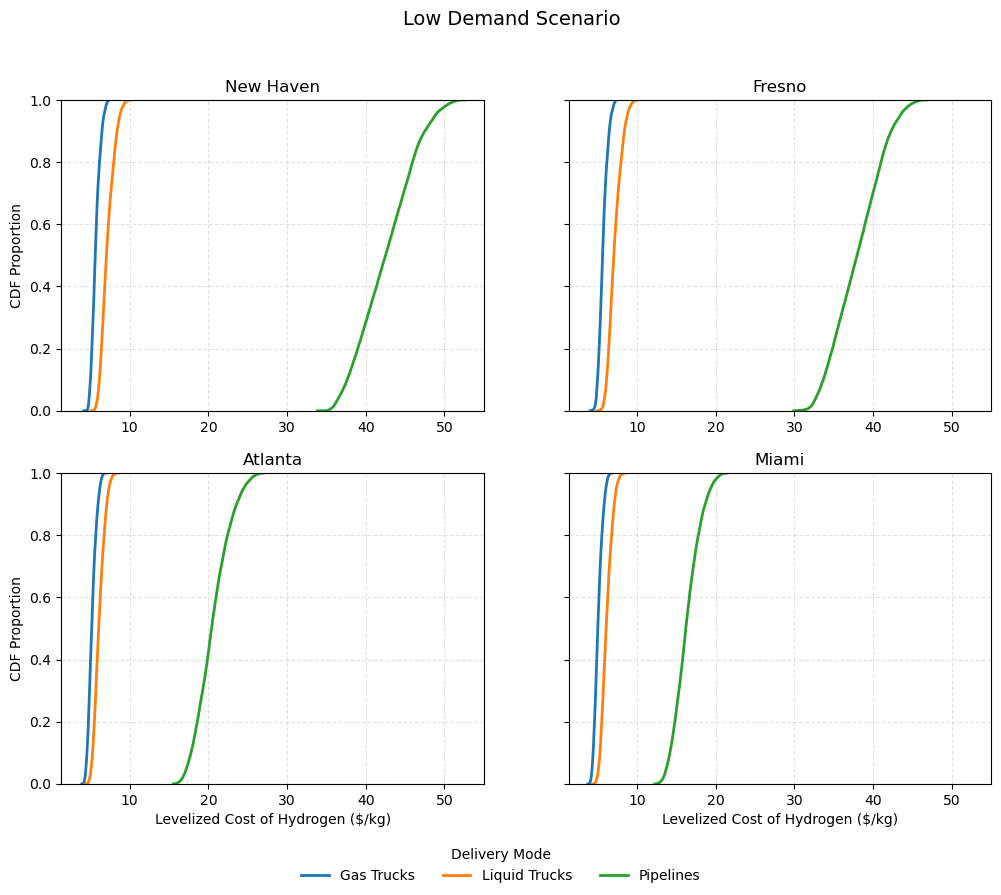


Running demand level: medium
  → Running city: New Haven
  → Running city: Fresno
  → Running city: Atlanta
  → Running city: Miami


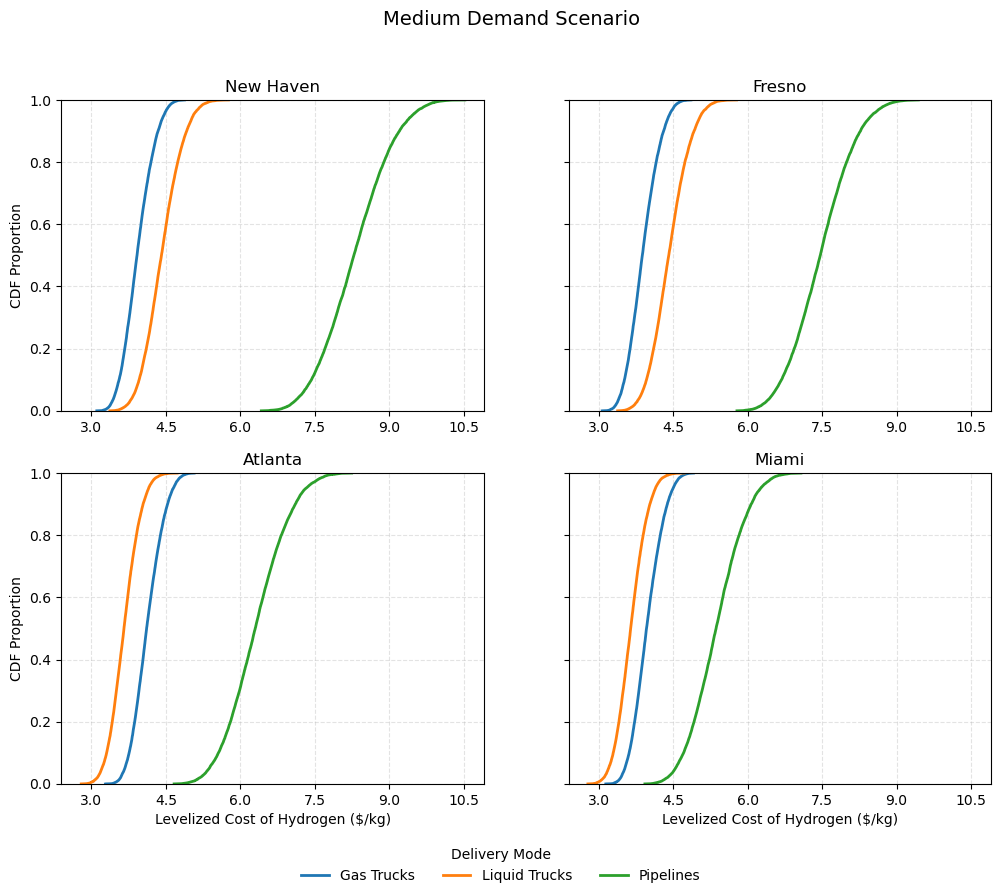


Running demand level: high
  → Running city: New Haven
  → Running city: Fresno
  → Running city: Atlanta
  → Running city: Miami


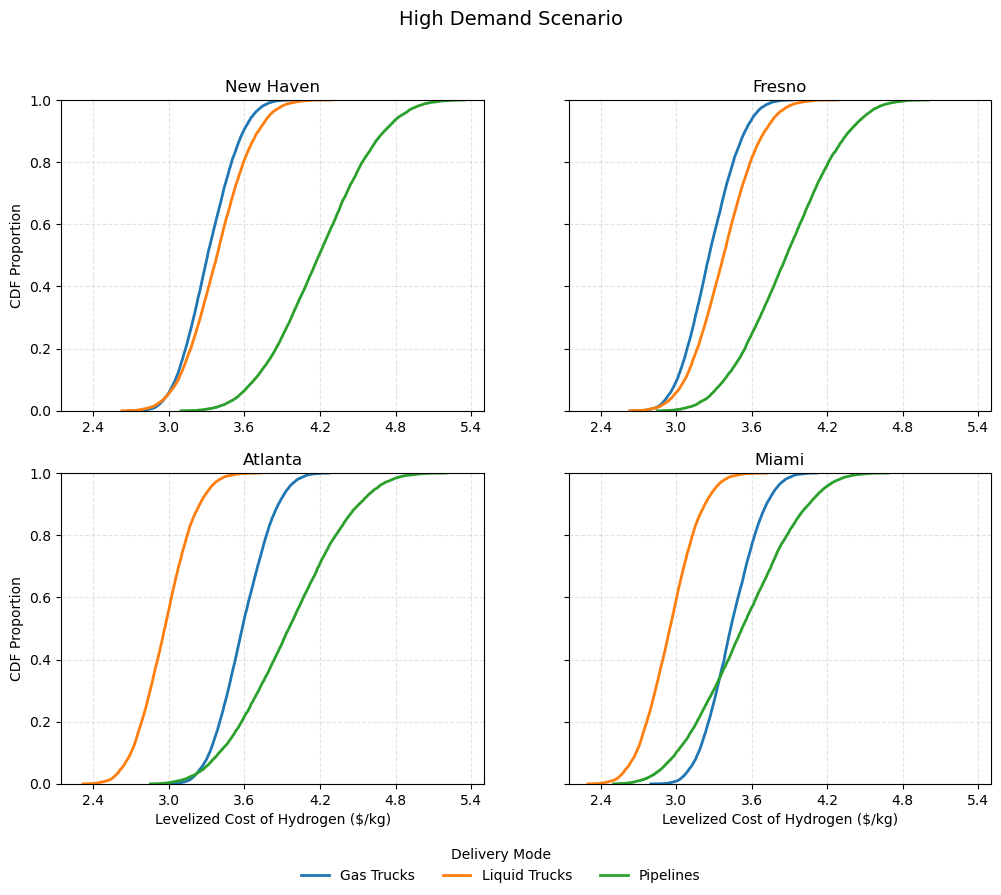

In [253]:
cities = ["New Haven", "Fresno", "Atlanta", "Miami"]
demands = ["low", "medium", "high"]

for demand in demands:
    print(f"\nRunning demand level: {demand}")

    city_results = {}

    for city in cities:
        print(f"  → Running city: {city}")

        df = run_monte_carlo(
            city_name=city,
            demand_level=demand,
            station_size=DEMAND_SCENARIOS[demand]["station_size"],
            n_samples=10000
        )
        city_results[city] = df

    plot_demand_level_cdfs_matplotlib(demand, city_results)


In [261]:
def plot_city_histogram(ax, df, city_name, bins=40):
    """
    Overlay histograms of gas, liquid, and pipeline costs for one city.
    """

    ax.hist(
        df["gas_cost_w_CT"],
        bins=bins,
        density=True,
        alpha=0.5,
        label="Gas Trucks"
    )

    ax.hist(
        df["liquid_cost_w_CT"],
        bins=bins,
        density=True,
        alpha=0.5,
        label="Liquid Trucks"
    )

    ax.hist(
        df["pipe_cost_w_CT"],
        bins=bins,
        density=True,
        alpha=0.5,
        label="Pipelines"
    )

    ax.set_title(city_name)
    ax.set_xlabel("Levelized Cost of Hydrogen ($/kg)")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)


In [262]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_demand_level_histograms(demand_level, city_results):
    fig, axes = plt.subplots(
        2, 2, figsize=(12, 9),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    # ---- dynamic x-axis limits across ALL cities ----
    all_costs = []
    for df in city_results.values():
        for col in ["gas_cost_w_CT", "liquid_cost_w_CT", "pipe_cost_w_CT"]:
            all_costs.extend(df[col])

    xmin = min(all_costs)
    xmax = max(all_costs)
    span = xmax - xmin
    xlim = (max(0, xmin - 0.05 * span), xmax + 0.05 * span)

    # ---- plot each city ----
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_city_histogram(ax, df, city)
        ax.set_xlim(xlim)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune="both"))

    # ---- force x tick labels everywhere (same fix as CDFs) ----
    for ax in axes:
        ax.tick_params(axis="x", labelbottom=True)

    # ---- single global legend ----
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        title="Delivery Mode",
        frameon=False
    )

    fig.subplots_adjust(bottom=0.12)
    fig.suptitle(
        f"{demand_level.capitalize()} Demand Scenario",
        fontsize=14
    )

    plt.show()


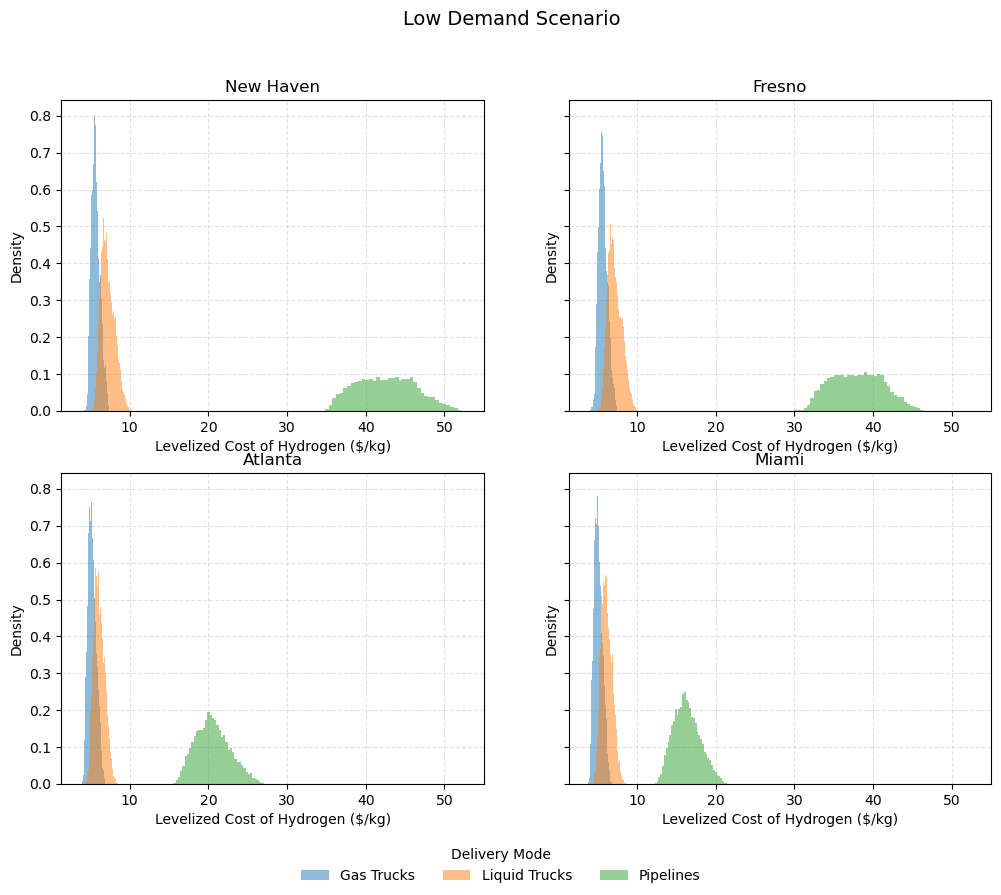

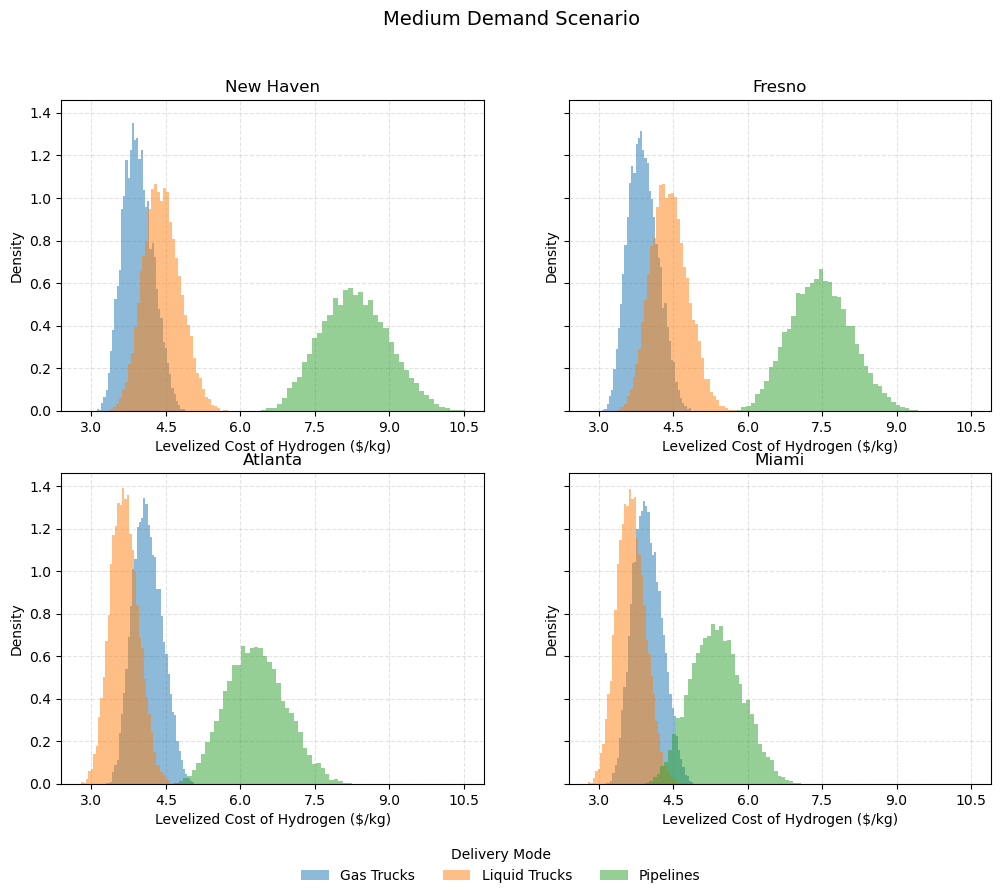

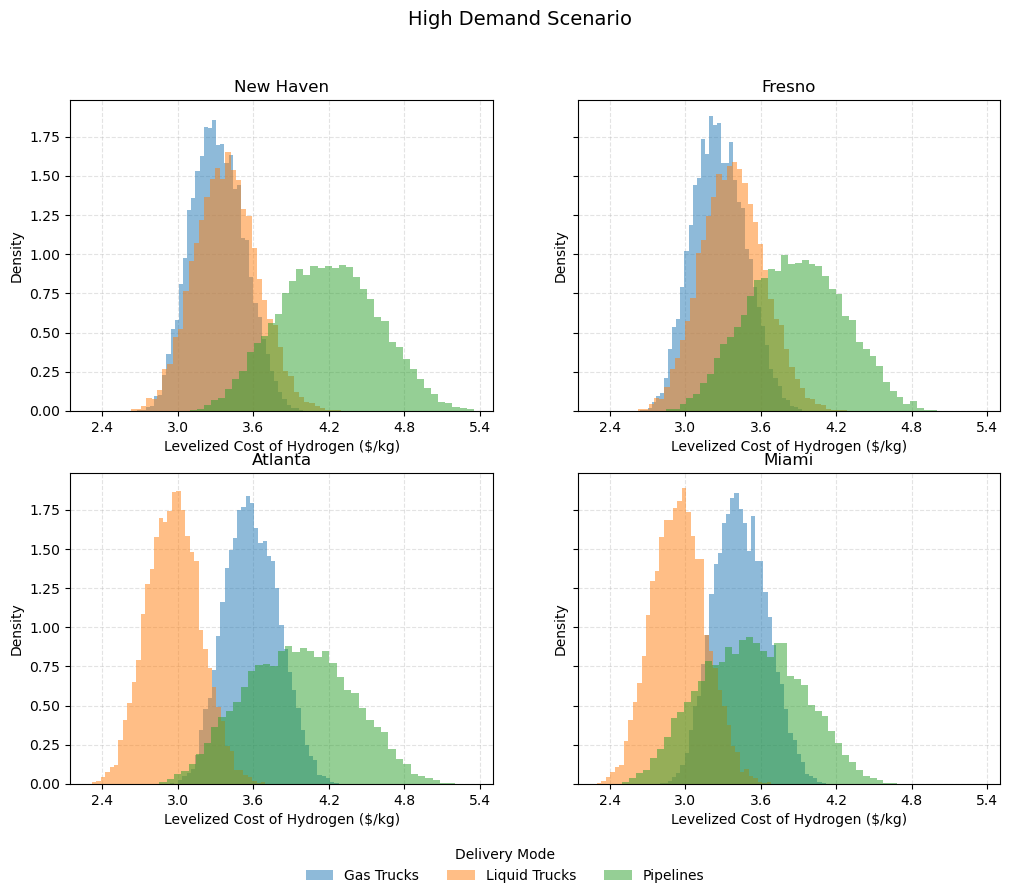

In [263]:
cities = ["New Haven", "Fresno", "Atlanta", "Miami"]

for demand in ["low", "medium", "high"]:
    city_results = {}

    for city in cities:
        df = run_monte_carlo(
            city_name=city,
            demand_level=demand,
            station_size=DEMAND_SCENARIOS[demand]["station_size"],
            n_samples=10000
        )
        city_results[city] = df

    plot_demand_level_histograms(demand, city_results)


In [194]:
import numpy as np
import pandas as pd

from SALib.sample import saltelli
from SALib.analyze import sobol

import matplotlib.pyplot as plt


In [195]:
problem = {
    "num_vars": 8,
    "names": [
        "cab_cost",
        "fuel_economy",
        "fuel_price",
        "electricity_cost",
        "liquefaction_eff",
        "compression_eff",
        "station_utilization",
        "h_fuel_ci"
    ],
    "bounds": [
        [200_000, 400_000],   # cab_cost ($)
        [7.9, 11.3],          # fuel_economy (mi/kg)
        [7, 15],              # fuel_price ($/kg)
        [0.06, 0.23],         # electricity_cost ($/kWh)
        [0.8, 1.2],           # liquefaction_eff (multiplier)
        [0.8, 1.2],           # compression_eff (multiplier)
        [0.30, 0.90],         # station_utilization
        [2000, 7000]          # hydrogen fuel CI (gCO2/kg)
    ]
}


In [196]:
N = 1024   # base sample size (safe starting point)

param_values = saltelli.sample(
    problem,
    N,
    calc_second_order=True
)


/var/folders/1w/y6djk8h939q0fqpl8nqbgc1c0000gn/T/ipykernel_38294/3347183926.py:3: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(


In [197]:
BASE_SAMPLE = {
    # -------------------------
    # Trucks
    # -------------------------
    "cab_cost": 350_000,
    "fuel_economy": 9.0,
    "fuel_price": 9.0,

    # -------------------------
    # Leakage — Transmission
    # -------------------------
    "leak_gas_truck_trans": 0.0106,
    "leak_liquid_truck_trans": 0.0255,
    "leak_pipeline_trans": 0.0003,

    # -------------------------
    # Leakage — Distribution
    # -------------------------
    "leak_gas_truck_dist": 0.0018,
    "leak_liquid_truck_dist": 0.0300,
    "leak_pipeline_dist": 0.0255,

    # -------------------------
    # Station losses
    # -------------------------
    "leak_gas_station": 0.0041,
    "leak_liquid_station": 0.0155,
    "leak_pipeline_station": 0.0041,

    # -------------------------
    # Operations
    # -------------------------
    "electricity_cost": 0.08,
    "station_utilization": 0.60,
    "liquefaction_eff": 1.0,
    "compression_eff": 1.0,

    # -------------------------
    # Emissions
    # -------------------------
    "h_fuel_ci": 4840,
    "electricity_ci": 369,

    # -------------------------
    # Capital multipliers
    # -------------------------
    "liq_cap_mult": 1.0,
    "comp_cap_mult": 1.0,
    "station_cap_mult": 1.0,
    "pipeline_cap_mult": 1.0,
}


In [198]:
def sobol_model(X):
    (
        cab_cost,
        fuel_economy,
        fuel_price,
        electricity_cost,
        liquefaction_eff,
        compression_eff,
        utilization,
        h_fuel_ci
    ) = X

    sample = BASE_SAMPLE.copy()
    sample.update({
        "cab_cost": cab_cost,
        "fuel_economy": fuel_economy,
        "fuel_price": fuel_price,
        "electricity_cost": electricity_cost,
        "liquefaction_eff": liquefaction_eff,
        "compression_eff": compression_eff,
        "station_utilization": utilization,
        "h_fuel_ci": h_fuel_ci
    })

    apply_sample(sample)

    out = run_system(
        city_name="Fresno",
        demand_level="medium",
        station_size=2000
    )

    return out["pipeline_cost"]


In [199]:
Y = np.array([sobol_model(x) for x in param_values])


In [200]:
Si = sobol.analyze(
    problem,
    Y,
    calc_second_order=True
)


In [201]:
print("Sobol Sensitivity Indices\n")

for name, s1, st in zip(problem["names"], Si["S1"], Si["ST"]):
    print(f"{name:25s}  S1 = {s1:6.3f}   ST = {st:6.3f}")


Sobol Sensitivity Indices

cab_cost                   S1 =  0.049   ST =  0.870
fuel_economy               S1 =  0.024   ST =  0.839
fuel_price                 S1 =  0.030   ST =  0.916
electricity_cost           S1 =  0.114   ST =  1.028
liquefaction_eff           S1 = -0.014   ST =  0.903
compression_eff            S1 =  0.078   ST =  0.933
station_utilization        S1 =  0.048   ST =  0.917
h_fuel_ci                  S1 =  0.038   ST =  0.841
